In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

x_img = cv2.imread("Lab0dados/lena.tif")

print(x_img.dtype)
print(x_img.shape)

uint8
(512, 512, 3)


In [3]:
cv2.imwrite("file1.jpg", x_img, (cv2.IMWRITE_JPEG_QUALITY, 80))
cv2.imwrite("file2.jpg", x_img, (cv2.IMWRITE_JPEG_QUALITY, 10))

True

In [4]:
Ia = plt.imread("file1.jpg")
Ib = plt.imread("file2.jpg")

MSE = np.mean((Ia - Ib) ** 2)

Ic = Ia * 1
Id = Ib * 1
MSE = np.mean((Ic - Id) ** 2)

Porg = np.mean(Ic ** 2)
Perr = np.mean((Ic - Id) ** 2)
SNR = 10 * np.log10(Porg / Perr)
print("SNR (dBs): ", SNR)

PSNR = 10 * np.log10(255 ** 2 / Perr)
print("PSNR (dBs): ", PSNR)

SNR (dBs):  3.211537646538954
PSNR (dBs):  31.06790165985945


In [5]:
x_img_g = cv2.cvtColor(x_img, cv2.COLOR_BGR2GRAY)
cv2.imwrite("file3.bmp", x_img_g)

print(x_img_g.shape)

(512, 512)


4. O histograma é uma ferramenta fundamental que contabiliza a frequência de ocorrência
de cada nível de intensidade na imagem.

Eixo X: Representa os níveis de cinzento, variando de 0 (Preto) e 255 (Branco).

Eixo Y: Representa o número de pixéis (frequência) que possuem cada nível de intensidade.

(262144,)


/var/folders/q8/0zrhfvpj419gsw2hfmxv_klw0000gn/T/ipykernel_70678/3077081453.py:1: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(x_img_g.ravel(), 256, [0, 256])


215


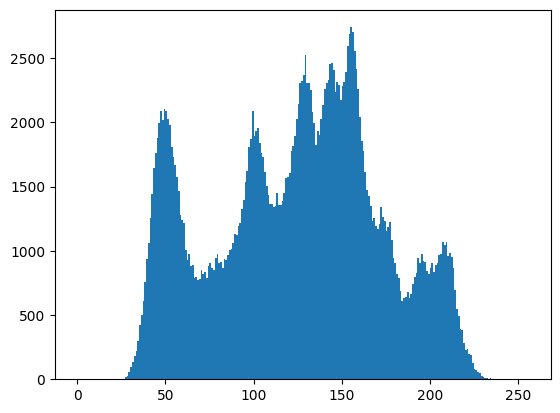

In [6]:
plt.hist(x_img_g.ravel(), 256, [0, 256])

print(x_img_g.ravel().shape)

Igray = plt.imread("file3.bmp")

ar = []
for i in x_img_g.ravel():
    if i in ar:
        continue
    else:
        ar.append(i)
print(len(ar))


5. Uma imagem em tons de cinzento de 8 bits pode ser visualizada como um conjunto de 8 planos 
binários (0 ou 1). Cada plano representa a contribuição de um bit específico para a 
intensidade total do pixel.

A extração é feita utilizando operações de deslocamento de bits (>>) e o operador lógico
AND (ou módulo 2, %2). O plano n é extraido deslocando os bits n - 1 vezes para a direita
e isolando o bit menos significativo.

Bits mais significativos (MSB) contêm a maior parte dos dados visuais e a estrutura principal
da imagem (bit 8 e 7)

Bits intermédios começam a mostrar detalhes mais finos e texturas, mas a estrutura ainda é 
reconhecível (bit 6 a 4)

Bits menos significativos (LSB) parece frequentemente ruído aleatório. 
Contêm detalhes impercetíveis ao olho humano. São frequentemente utilizados em técnicas
de Esteganografia (esconder dados dentro de imagens) porque a sua alteração não modifica
visualmente a imagem original.

Text(0.5, 1.0, 'bit8')

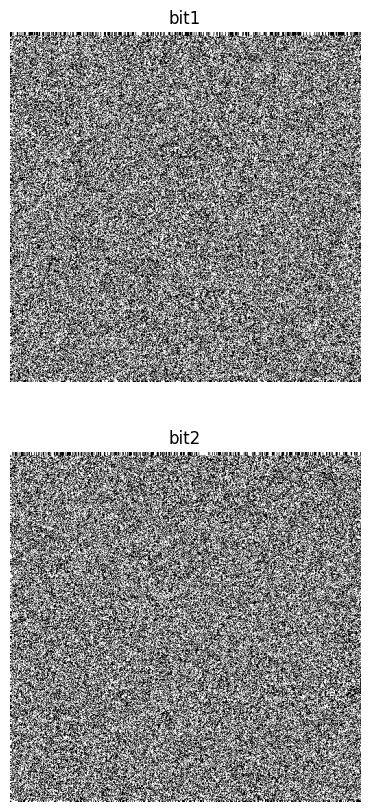

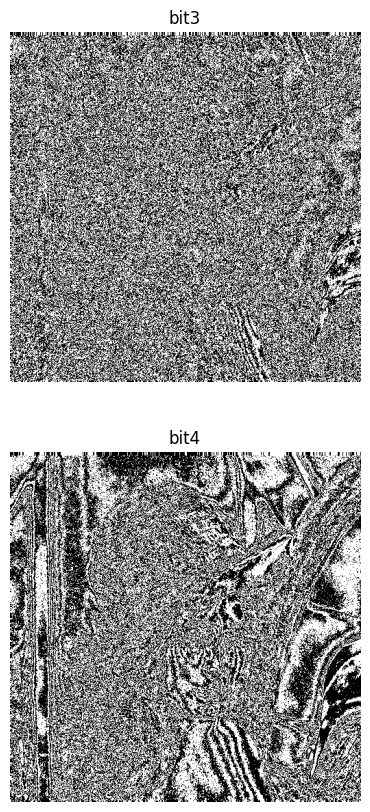

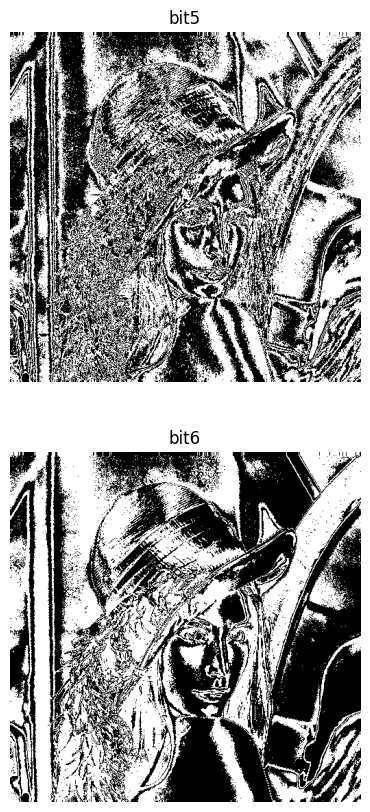

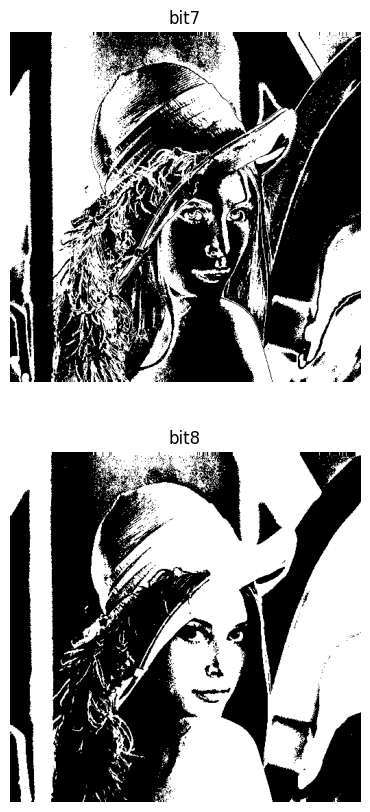

In [7]:
plt.figure(figsize=(20, 10))
plt.subplot(211)
I1 = (Igray%2)*255
plt.imshow(I1, cmap="gray")
plt.axis('off')
plt.title('bit1')
plt.subplot(212)
I2 = ((Igray>>1)%2)*255
plt.imshow(I2, cmap='gray')
plt.axis('off')
plt.title('bit2')
plt.figure(figsize=(20, 10))
plt.subplot(211)
I3 = ((Igray>>2)%2)*255
plt.imshow(I3, cmap='gray')
plt.axis('off')
plt.title('bit3')
plt.subplot(212)
I4 = ((Igray>>3)%2)*255
plt.imshow(I4, cmap='gray')
plt.axis('off')
plt.title('bit4')   
plt.figure(figsize=(20, 10))
plt.subplot(211)
I5 = ((Igray>>4)%2)*255
plt.imshow(I5, cmap='gray')
plt.axis('off')
plt.title('bit5')   
plt.subplot(212)
I6 = ((Igray>>5)%2)*255
plt.imshow(I6, cmap='gray')
plt.axis('off')
plt.title('bit6')
plt.figure(figsize=(20, 10))
plt.subplot(211)
I7 = ((Igray>>6)%2)*255
plt.imshow(I7, cmap='gray')
plt.axis('off')
plt.title('bit7')   
plt.subplot(212)
I8 = ((Igray>>7)%2)*255
plt.imshow(I8, cmap='gray')
plt.axis('off')
plt.title('bit8')


6. O objetivo do dithering é reduzir a profundidade de cor de uma imagem mantendo a ilusão
visual de gradação tonal. O algoritmo utilizado foi o de Difusão de Erro.
    Conceito de Difusão de Erro: Quando um pixel é quantizado (transformado em 0 ou 255),
        ocorre uma perda de informação (o "erro"). Este erro é "espalhado" para os pixeis
        vizinhos que ainda não foram processados.

    A Matriz de Pesos: O algoritmo de Floyd-Steinberg distribui o erro seguindo proporções 
    específicas:
        À direita: 7/16
        Abaixo à esquerda: 3/16
        Abaixo: 5/16
        Abaixo à direita: 1/16

O código verifica se o pixel atual está na última linha ou úlitma coluna para evitar erros de índice
(IndexError), garantindo que o erro não seja "empurrado" para fora dos limites da matriz.
A imagem é convertida para float antes do processamento. Isso é importante porque os erros
acumulados são frações e, se usasse uint8 (inteiros), os arredondamentos destruiram o efeito
do dithering.

[[162 162 162 ... 170 155 128]
 [162 162 162 ... 170 155 128]
 [162 162 162 ... 170 155 128]
 ...
 [ 43  43  50 ... 104 100  98]
 [ 44  44  55 ... 104 105 108]
 [ 44  44  55 ... 104 105 108]]
[[255.   0. 255. ... 255. 255.   0.]
 [255. 255.   0. ... 255.   0. 255.]
 [  0. 255. 255. ... 255. 255.   0.]
 ...
 [  0.   0.   0. ...   0.   0. 255.]
 [  0.   0.   0. ... 255.   0.   0.]
 [  0. 255.   0. ... 255.   0. 255.]]


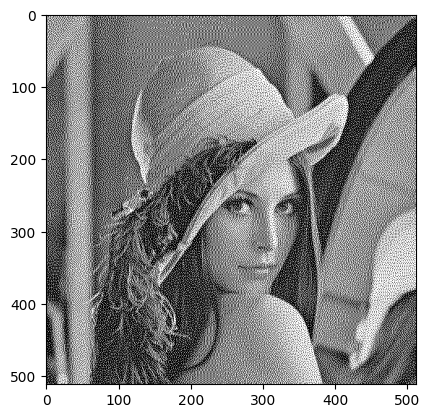

In [8]:
#Ex 6
"""
def dither(ar):
    for i in range(len(ar)):
        for j in range(len(ar[i])):
            #ultima linha e ultima coluna
            if i == len(ar) - 1 and  j == len(ar[i]) - 1:
                pass
            #ultima linha
            elif i == len(ar) - 1:
                ar[i, j + 1] = ar[i, j + 1] * (7/16)
            #primeira coluna
            elif j == 0:
                ar[i, j + 1] = ar[i, j + 1] * (7/16)
                ar[i + 1, j] = ar[i + 1, j] * (5/16)
                ar[i + 1, j + 1] = ar[i + 1, j + 1] * (1/16)
            #ultima coluna
            elif j == len(ar[i]) - 1:
                ar[i + 1, j - 1] = ar[i + 1, j - 1] * (3/16)
                ar[i + 1, j] = ar[i + 1, j] * (5/16)
            #geral
            else:
                ar[i, j + 1] = ar[i, j + 1] * (7/16)
                ar[i + 1, j - 1] = ar[i + 1, j - 1] * (3/16)
                ar[i + 1, j] = ar[i + 1, j] * (5/16)
                ar[i + 1, j + 1] = ar[i + 1, j + 1] * (1/16)
    print(ar)
    return ar
"""

def quant(v):
    if v >= 128:
        return 255
    else:
        return 0

def dither(ar):
    height = len(ar)
    width = len(ar[0])
    ar = ar.astype(float)
    for i in range(len(ar)):
        for j in range(len(ar[0])):
            op = ar[i][j]
            np = quant(op)
            ar[i][j] = np
            erro = op - np

            #ultima linha e ultima coluna
            if i == height - 1 and  j == width - 1:
                pass
            #ultima linha
            elif i == height - 1:
                ar[i][j + 1] += (erro * (7/16))
            #primeira coluna
            elif j == 0:
                ar[i][j + 1] += (erro * (7/16))
                ar[i + 1][j] += (erro * (5/16))
                ar[i + 1][j + 1] += (erro * (1/16))
            #ultima coluna
            elif j == width - 1:
                ar[i + 1][j - 1] += (erro *(3/16))
                ar[i + 1][j] += (erro * (5/16))
            #geral
            else:
                ar[i][j + 1] += (erro * (7/16))
                ar[i + 1][j - 1] += (erro *(3/16))
                ar[i + 1][j] += (erro * (5/16))
                ar[i + 1][j + 1] += (erro * (1/16))
    return ar
            
           
        

y = dither(x_img_g)
print(x_img_g)
print(y)

plt.imshow(y, cmap='gray')
plt.imsave("file4.bmp", y.astype(np.uint16), cmap='gray')

7. O objetivo foi converter a imagem processada numa representação binária para otimizar o
espaço em disco.
Binarização: A matriz foi convertida para um formato booleano (0 ou 1)
Empacotamento de Bits (np.packbits): Em vez de usar 1 byte (8 bits) para armazenar
cada pixel, a função agrupa 8 pixeis num único byte. Isso reduz o tamanho do ficheiro
em 8 vezes face a um formato de imagem não comprimido de 1 bit

Para avaliar a degradação da imagem após a binarização, foram utilizadas métricas
estatísticas de erro:

Erro Quadrático Médio (MSE): O MSE mede a diferença média entre os pixéis da imagem
ordinal (Ia) e a processada (Ib).

Relação Sinal-Ruído (SNR): A SNR compara a potência do sinal original com a potência
do ruído (erro), quanto maior a SNR mais próxima a imagem processada está da original,
valores baixos indicam que o processamento introduziu alterações significativas
(neste caso, a binarização por setores).



In [12]:
"""def binarizar_imagem(filepath):
    I = cv2.imread(filepath, 0)
    limFixo = I.mean()
    I1 = (255*(I>limFixo)).astype('uint8')
    plt.figure(figsize=(20, 10))
    plt.subplot(131)
    plt.imshow(I, cmap='gray')
    plt.axis('off')

    plt.subplot(132)
    plt.imshow(I1, cmap='gray')
    plt.axis('off')

    plt.imsave("file4binario.bmp", I1, cmap='gray')

    return I, I1

    
Ia, Ib = binarizar_imagem("file4.bmp")

print(Ib)

MSE = np.mean((Ia - Ib) ** 2)

Porg = np.mean(Ia ** 2)
Perr = np.mean((Ia - Ib) ** 2)
SNR = 10 * np.log10(Porg / Perr)
print("SNR (dBs): ", SNR)

PSNR = 10 * np.log10(255 ** 2 / Perr)
print("PSNR (dBs): ", PSNR)   
"""

import os

def gravar_binario(matriz, filename):
    matriz_bool = (matriz > 0).astype(np.uint8)

    bits_compactados = np.packbits(matriz_bool)

    with open(filename, 'wb') as f:
        bits_compactados.tofile(f)

    return os.path.getsize(filename)

caminho_original = "file4.bmp"
caminho_binario = "imagem_compactada.bin"

tamanho_original = os.path.getsize(caminho_original)
tamanho_final = gravar_binario(Ib, caminho_binario)

taxa_compressao = tamanho_original / tamanho_final

print(f"tamanho original : {tamanho_original} bytes")
print(f"Tamanho Final: {tamanho_final} bytes")
print(f"Taxa de Compressão: {taxa_compressao:.2f}:1")

mse = np.mean((Ia.astype(float) - Ib.astype(float)) ** 2)
p_sinal = np.mean(Ia.astype(float) ** 2)

snr_calc = 10 * np.log10(p_sinal / mse)
psnr_calc = 10 * np.log10(255*2 / mse)

print(f"SNR: {snr_calc:.2f} db")
print(f"PSNR: {psnr_calc:.2f} db")

tamanho original : 1048630 bytes
Tamanho Final: 32768 bytes
Taxa de Compressão: 32.00:1
SNR: inf db
PSNR: inf db


/var/folders/q8/0zrhfvpj419gsw2hfmxv_klw0000gn/T/ipykernel_70678/3992979054.py:61: RuntimeWarning: divide by zero encountered in scalar divide
  snr_calc = 10 * np.log10(p_sinal / mse)
/var/folders/q8/0zrhfvpj419gsw2hfmxv_klw0000gn/T/ipykernel_70678/3992979054.py:62: RuntimeWarning: divide by zero encountered in scalar divide
  psnr_calc = 10 * np.log10(255*2 / mse)


8. A geração da imagem baseia-se na conversão de coordenadas cartesianas (x,y) para coordenadas polares,
especificamente focando-se no componente angular θ.

Espaço de Coordenadas: Define-se uma grelha de N x N pontos normalizada no intervalo [-1, 1],

Cálculo do Ângulo: Utiliza-se a função arctan2(y, x) para obter o ângulo de cada pixel em relação 
ao centro da imagem. A fórmula matemática aplicada é 
            θ=atan2(−y,x)

Normalização: Como o resultado de arctan2 é dado em radianos no intervalo [−π,π],
os valores são convertidos para graus e normalizados para o intervalo [0, 360º[ através
da operação de módulo.  

A criação do padrão alternado é feita através de uma operação de discretização angular:
    1. Divisão Inteira: Divide-se o ângulo de cada pixel pelo parâmetro degrees.
    2. Alternância Binária: Aplica-se o operador módulo 2 (%2) ao índice do setor.
        Isto resulta em:
        0 para setores pares (cor preta)
        1 para setores ímpares (cor branca)
    3. O resultado binário é multiplicado por 255 para atingir a intensidade máxima 
    da escala de cinza de 8 bits.

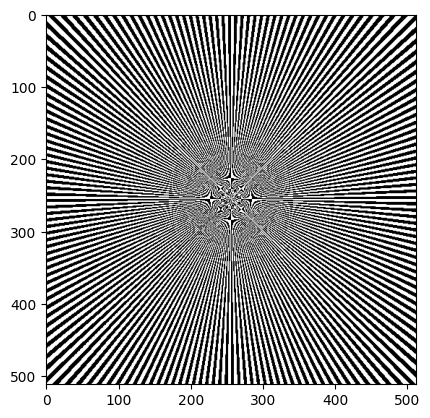

In [10]:
def generateimg(N, degrees):
    x = np.linspace(-1, 1, N)
    y = np.linspace(-1, 1, N)
    xv, yv = np.meshgrid(x, y)

    angulos_img = np.arctan2(-yv, xv)
    angulos_img = np.degrees(angulos_img) % 360

    imagem = ((angulos_img // degrees) % 2) * 255

    return imagem.astype(np.uint8)

imagem = generateimg(512, 1)
plt.imshow(imagem, cmap='gray')
plt.show()

9a. O primeiro passo consistiu na leitura da imagem xpto3.jpeg em tons de cinzento (grayscale)
É verificado depois o histograma para verificação, no ínicio a distribuição de intensidades
é ao longo de todo o espectro [0, 255], no fim só tem para 0(Preto) e 255(Branco).

(array([ 33256.,      0.,      0.,      0.,      0.,      0.,      0.,
             0.,      0., 221444.]),
 array([  0. ,  25.5,  51. ,  76.5, 102. , 127.5, 153. , 178.5, 204. ,
        229.5, 255. ]),
 <BarContainer object of 10 artists>)

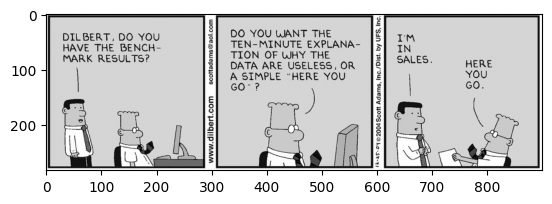

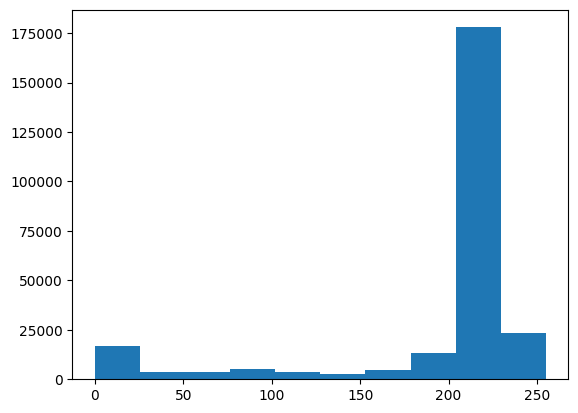

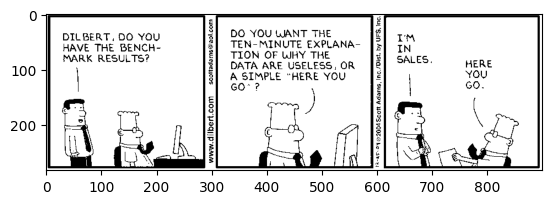

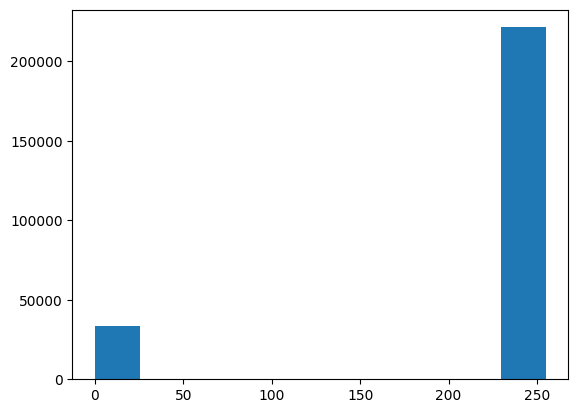

In [11]:
img_xpto = cv2.imread("xpto3.jpeg", 0)

plt.imshow(img_xpto, cmap='gray')

plt.figure()
plt.hist(img_xpto.ravel())

transform_img_xpto = img_xpto.ravel()

new_imgxpto = []

for i in range(len(transform_img_xpto)):
    if transform_img_xpto[i] >= 128:
        new_imgxpto.append(255)
    else:
        new_imgxpto.append(0)       

y_img = np.array(new_imgxpto).reshape(img_xpto.shape)

plt.figure()

plt.imshow(y_img, cmap='gray')

plt.figure()

plt.hist(y_img.ravel())